In [1]:
import sys
# Add your lenscarf site-packages to the path
sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')

import numpy as np
import readgadget
import MAS_library as MASL
import Pk_library as PKL

import smoothing_library as SL

In [2]:
simidx = 0
snapshot = f'/users/odarwish/scratch/quijote/snapshots/{simidx}/snapdir_004/snap_004' #location of the snapshot
grid     = 1024    #the density field will have grid^3 voxels
MAS      = 'CIC'  #Mass-assignment scheme:'NGP', 'CIC', 'TSC', 'PCS'
verbose  = True   #whether to print information about the progress
ptype    = [1]    #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)

# read header
header   = readgadget.header(snapshot)
BoxSize  = header.boxsize/1e3  #Mpc/h
redshift = header.redshift     #redshift of the snapshot
Masses   = header.massarr*1e10 #Masses of the particles in Msun/h

# read positions, velocities and IDs of the particles
pos = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h

print('BoxSize: %.3f Mpc/h'%BoxSize)
print('Redshift: %.3f'%redshift)
print('%.3f < X < %.3f'%(np.min(pos[:,0]), np.max(pos[:,0])))
print('%.3f < Y < %.3f'%(np.min(pos[:,1]), np.max(pos[:,1])))
print('%.3f < Z < %.3f'%(np.min(pos[:,2]), np.max(pos[:,2])))

BoxSize: 1000.000 Mpc/h
Redshift: 0.000
0.000 < X < 999.992
0.000 < Y < 999.992
0.000 < Z < 999.992


In [3]:
# read header
icsdir = f'/users/odarwish/scratch/quijote/snapshots/{simidx}/ICs/ics'
header_ics   = readgadget.header(icsdir)
BoxSize_ics  = header_ics.boxsize/1e3  #Mpc/h
redshift_ics = header_ics.redshift     #redshift of the snapshot
Masses_ics   = header_ics.massarr*1e10 #Masses of the particles in Msun/h

# read positions, velocities and IDs of the particles
pos_ics = readgadget.read_block(icsdir, "POS ", ptype)/1e3 #positions in Mpc/h

In [5]:
import sys
sys.path.append('/users/odarwish/nbodykit/')
import nbodykit
from nbodykit.lab import ArrayCatalog, ArrayMesh

data = {
    'Position': pos
}
catalog = ArrayCatalog(data)
catalog.attrs['BoxSize'] = BoxSize
catalog.attrs['Redshift'] = redshift
catalog.attrs['Mass'] = Masses

mesh = catalog.to_mesh(
    resampler='tsc',
    Nmesh=grid,           # Number of mesh cells per dimension
    #resampler='cic',     # Resampling method: 'ngp', 'cic', 'tsc', 'pcs'
    compensated=True     # Apply compensation for the resampling window
)
density = mesh.compute(mode="real")

ModuleNotFoundError: No module named 'mpi4py'

In [5]:
one_plus_delta = mesh.paint(mode='real')
delta = one_plus_delta-1 

In [6]:
np.mean(one_plus_delta), np.mean(density)

(0.999994, 0.999994)

In [7]:
np.min(one_plus_delta), np.max(one_plus_delta)

(-647.56885, 7186.953)

In [8]:
data = {
    'Position': pos_ics
}
catalog_ics = ArrayCatalog(data)
catalog_ics.attrs['BoxSize'] = BoxSize_ics
catalog_ics.attrs['Redshift'] = redshift_ics
catalog_ics.attrs['Mass'] = Masses_ics

mesh_ics = catalog_ics.to_mesh(
    Nmesh=grid,           # Number of mesh cells per dimension
    resampler='cic',     # Resampling method: 'ngp', 'cic', 'tsc', 'pcs'
    compensated=True     # Apply compensation for the resampling window
)
density_ics = mesh_ics.compute(mode="real")

In [9]:
one_plus_delta_ics = mesh_ics.paint(mode='real')
delta_ics = one_plus_delta_ics-1 

In [10]:
np.mean(delta_ics), np.min(delta_ics)

(-5.6506906e-09, -6.407763)

### Let's take the power spectrum

In [11]:
import camb
from camb import model

#params_file = "/users/odarwish/scratch/quijote/fiducial/CAMB_TABLES/CAMB_params.ini"
#pars = camb.read_ini(params_file)
#results = camb.get_results(pars)

power = np.loadtxt("/users/odarwish/scratch/quijote/fiducial/CAMB_TABLES/CAMB_matterpow_0.dat").T

pars = camb.CAMBparams()

As = 2.13e-09
ns = 0.9624
Ωm = 0.3175
Ωb = 0.049
Ωc = Ωm-Ωb
h = 0.6711
σ8 = 0.834
Mν = 0.0 
fnl_loc= 0
kmax = 10.

pars.set_cosmology(H0=h*100, ombh2=Ωb*h**2, omch2=Ωc*h**2)
pars.InitPower.set_params(ns=ns, As=As)
#results = camb.get_results(pars)
pars.set_matter_power(redshifts=[0.], kmax=kmax)
pars.NonLinear = model.NonLinear_both
results = camb.get_results(pars)
kh_nonlin, z_nonlin, pk_nonlin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)

pars.NonLinear = model.NonLinear_none
results = camb.get_results(pars)
kh_lin, z_lin, pk_lin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)

In [12]:
import pyccl as ccl

As = 2.13e-09
ns = 0.9624
Omega_b = 0.049
Omega_c = 0.2685
h = 67.11/100
mnu = 0

cosmo = ccl.Cosmology(Omega_c = Omega_c, Omega_b = Omega_b, h = h, A_s = As, n_s = ns, m_nu = mnu)

a = 1/(1+127)
growthf = ccl.background.growth_factor(cosmo, a)

In [13]:
#np.savetxt("nonlinear_power_quijote.txt", np.c_[kh_nonlin, pk_nonlin[0]])
#np.savetxt("linear_power_quijote.txt", np.c_[kh_lin, pk_lin[0]])

In [14]:
from nbodykit.algorithms.fftpower import FFTPower

r = FFTPower(delta, mode='1d', kmin = 1e-2)
Pk = r.power

# Extract k and P(k)
kn = Pk['k']
powern = Pk['power'].real
modesn = Pk['modes']


r = FFTPower(delta_ics, mode='1d', kmin = 1e-2)
Pk_ics = r.power

# Extract k and P(k)
kn = Pk['k']
powern_ics = Pk_ics['power'].real
modesn = Pk['modes']

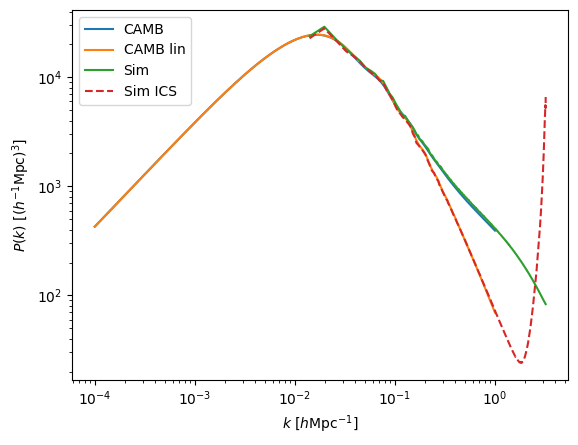

In [15]:
import matplotlib.pyplot as plt
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k~[h{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k)~[(h^{-1}{\rm Mpc})^3]$')


plt.loglog(kh_nonlin, pk_nonlin[0], label = "CAMB")
plt.loglog(kh_lin, pk_lin[0], label = "CAMB lin")


plt.plot(kn, powern, label = "Sim")
plt.plot(kn, powern_ics*growthf**-2, label = "Sim ICS", ls = "--")

plt.legend()
#plt.ylim(1e2)
plt.show()

In [16]:
import scipy
from scipy import interpolate as interp

plinf = interp.CubicSpline(kh_lin, pk_lin[0])
pnlinf = interp.CubicSpline(kh_nonlin, pk_nonlin[0])

In [17]:
psimf = interp.CubicSpline(kn, powern)

In [28]:
out = np.load("out.npy", allow_pickle = True).item()
out.keys()

def get_n_bias(key):
    Ks = out["Ks"]
    
    N = out[(key, key)]**-1.
    
    keys = ["g", "s", "t"]
    bias = 0
    for key_ in keys:
        try:
            invNk = out[(key, key_)]
        except:
            invNk = out[(key_, key)]
        bias += N*invNk
    return bias, N

biasg, Ng = get_n_bias("g")
biass, Ns = get_n_bias("s")

Pinterp = np.interp(Ks, kh_lin, pk_lin[0])

/tmp/ipykernel_120232/4221883831.py:7: RuntimeWarning: divide by zero encountered in reciprocal
  N = out[(key, key)]**-1.
/tmp/ipykernel_120232/4221883831.py:16: RuntimeWarning: invalid value encountered in multiply
  bias += N*invNk


In [19]:
from nbodykit.source.mesh.field import FieldMesh
import json

class Smoother(object):
    """
    Class to apply smoothing to field.
    """
    def __init__(self):
        raise NotImplementedError

    def get_smoothing_kernel_of_Nth_iteration(self, N):
        raise NotImplementedError


class HardSmoother(Smoother):
    """
    Apply Gaussian smoothing to field.
    """
    def __init__(
        self,
        kmin, kmax,
        name='HardSmoother'
        ):
        self.kmin = kmin
        self.kmax = kmax
        self.name = name

    def get_smoothing_kernel(self):
        kmin, kmax = self.kmin, self.kmax
        if kmin is None or kmax==0.:
            def kernel_fcn(k3vec, val):
                return val
        else:
            def kernel_fcn(k3vec, val):
                k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
                kmag = np.sqrt(k2)
                window = (kmag >= kmin) & (kmag <= kmax)
                return  window * val
        return kernel_fcn

    def apply_smoothing(self, meshsource):
        # make a copy
        out = FieldMesh(meshsource.compute(mode='complex'))
        kernel_fcn = self.get_smoothing_kernel()
        out = out.apply(kernel_fcn, kind='wavenumber', mode='complex')
        return out

    def to_dict(self):
        return dict(
            kmin=self.kmin, kmax = self.kmax, name=self.name)

    def __str__(self):
        return json.dumps(self.to_dict())

    def __repr__(self):
        return self.__str__()
    

kmin, kmax = 0.051, 0.15
smoother = HardSmoother(kmin, kmax)
delta_mesh = FieldMesh(density)
delta_mesh_smoothed = smoother.apply_smoothing(delta_mesh)

In [20]:
def ivf_operator(k3vec, val):
    k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
    kmag = np.sqrt(k2)
    pnlinear_interp = pnlinf(kmag)
    return 1/pnlinear_interp*val

def growth_estimator(k3vec, val):
    Fg = 5/7
    k2 = np.sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
    kmag = np.sqrt(k2)
    plinear_interp = plinf(kmag)
    return Fg*plinear_interp*val

def new_shift_estimator(k3vec, val):
    i = 0
    Fs = 0.5*k3vec[i]
    k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
    kmag = np.sqrt(k2)
    plinear_interp = plinf(kmag)
    kmag[kmag == 0] = 1
    return Fs*plinear_interp*val/kmag


out = FieldMesh(delta_mesh_smoothed.compute(mode='complex'))
delta_ivf = out.apply(ivf_operator, kind='wavenumber', mode='complex')

out = FieldMesh(delta_ivf.compute(mode='complex'))
delta_wf = out.apply(growth_estimator, kind='wavenumber', mode='complex')

#out = FieldMesh(delta_ivf.compute(mode='complex'))
#delta_wf_shift = out.apply(new_shift_estimator, kind='wavenumber', mode='complex')

In [21]:
delta_ivf_real = delta_ivf.compute(mode="real")
delta_wf_real = delta_wf.compute(mode="real")

/tmp/ipykernel_120232/2604760570.py:9: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  k2 = np.sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh


In [36]:
#0.5*(q/K+K/q)*q_i*K_i/q/K
#0.5*(1/K**2+1/q**2)*q_i*K_i
#1/K**2*K_i* q_i + K_i * 1/q**2*q_i

#(1/q**2+1/K**2)*(-q_i)*K_i

#1/q**2*(-q_i)*K_i d_q d_q'

result = 0.

for i in range(3):
    def shift_estimator_A(k3vec, val, idir = i):
        k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
        kmag = np.sqrt(k2)
        plinear_interp = plinf(kmag)
        kmag[kmag == 0] = 1
        return -k3vec[idir]*plinear_interp*val/kmag**2
    
    def shift_estimator_A_(k3vec, val, idir = i):
        #k2 = sum(ki**2 for ki in k3vec)
        return k3vec[idir]
    
    def shift_estimator_B(k3vec, val, idir = i):
        k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
        kmag = np.sqrt(k2)
        plinear_interp = plinf(kmag)
        kmag[kmag == 0] = 1
        return -k3vec[idir]*plinear_interp*val
    
    def shift_estimator_B_(k3vec, val, idir = i):
        k2 = sum(ki**2 for ki in k3vec)
        k2[k2 == 0] = 1
        return k3vec[idir]/k2


    out = FieldMesh(delta_ivf.compute(mode='complex'))
    delta_A = out.apply(shift_estimator_A, kind='wavenumber', mode='complex')
    prod_A = (FieldMesh(delta_A.compute(mode="real")*delta_ivf_real))#.compute(mode='complex')
    part_A = (prod_A.apply(shift_estimator_A_, kind='wavenumber', mode='complex')).compute(mode="real")
    
    out = FieldMesh(delta_ivf.compute(mode='complex'))
    delta_B = out.apply(shift_estimator_B, kind='wavenumber', mode='complex')
    prod_B = (FieldMesh(delta_B.compute(mode="real")*delta_ivf_real))#.compute(mode='complex')
    part_B = (prod_B.apply(shift_estimator_B_, kind='wavenumber', mode='complex')).compute(mode="real")
    
    part = 0.5*(part_A+part_B)
    result += part

RealField:array([[[-1.79085375e+06, -1.27740938e+04,  1.35591260e+03, ...,
         -7.15357300e+02,  1.35591260e+03, -1.27740938e+04],
        [-1.27740928e+04, -2.88167236e+03,  1.34179382e+02, ...,
         -1.17126587e+02,  1.34179382e+02, -2.88167212e+03],
        [ 1.35591235e+03,  1.34179413e+02, -4.18425217e+01, ...,
          1.16064186e+01, -4.18425217e+01,  1.34179398e+02],
        ...,
        [-7.15357239e+02, -1.17126587e+02,  1.16064129e+01, ...,
         -6.35065079e+00,  1.16064224e+01, -1.17126549e+02],
        [ 1.35591235e+03,  1.34179398e+02, -4.18425179e+01, ...,
          1.16064148e+01, -4.18425217e+01,  1.34179398e+02],
        [-1.27740918e+04, -2.88167236e+03,  1.34179352e+02, ...,
         -1.17126602e+02,  1.34179382e+02, -2.88167212e+03]],

       [[ 1.79085100e+06, -3.93020192e+08, -1.50306140e+07, ...,
          1.33336016e+08,  1.50279020e+07,  3.93045760e+08],
        [ 1.27741582e+04, -1.08234980e+07, -7.02119750e+06, ...,
          5.73626000e+06,  7

In [23]:
boxsize = BoxSize
k_bin_width = 1.0
dk = 2.0 * np.pi / boxsize * k_bin_width
kmin = 2.0 * np.pi / boxsize / 2.0

from nbodykit.algorithms.fftpower import FFTPower

growth_nbody = delta_ivf_real*delta_wf_real

r = FFTPower(growth_nbody, mode='1d')
Pk = r.power

# Extract k and P(k)
kn = Pk['k']
powergn = Pk['power'].real
modesn = Pk['modes']

In [37]:
r = FFTPower(result, mode='1d')
Pk = r.power

# Extract k and P(k)
kn = Pk['k']
powersn = Pk['power'].real
modesn = Pk['modes']

In [24]:
r = FFTPower(growth_nbody, second = delta_ics, mode='1d')
Pk = r.power

# Extract k and P(k)
kn = Pk['k']
powergn_ics = Pk['power'].real
modesn = Pk['modes']


r = FFTPower(growth_nbody, second = delta, mode='1d')
Pk = r.power

# Extract k and P(k)
kn = Pk['k']
powergn_delta = Pk['power'].real
modesn = Pk['modes']

In [38]:
r = FFTPower(result, second = delta_ics, mode='1d')
Pk = r.power

# Extract k and P(k)
kn = Pk['k']
powersn_ics = Pk['power'].real
modesn = Pk['modes']


r = FFTPower(result, second = delta, mode='1d')
Pk = r.power

# Extract k and P(k)
kn = Pk['k']
powersn_delta = Pk['power'].real
modesn = Pk['modes']

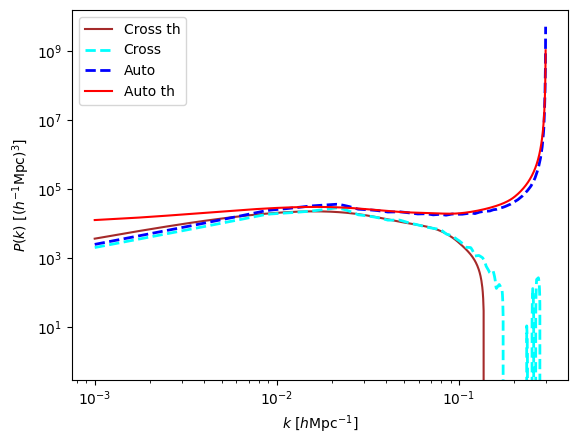

In [26]:
import matplotlib.pyplot as plt
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k~[h{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k)~[(h^{-1}{\rm Mpc})^3]$')

fac = 1#Ks**4
plt.plot(Ks, (fac*biasg*Pinterp), color= "brown", label = "Cross th")
plt.plot(Ks, (fac*np.interp(Ks, kn, powergn_ics*growthf**-1.)*Ng), lw = 2, color = "cyan", ls = "--", label = "Cross")

plt.plot(Ks, (fac*np.interp(Ks, kn, powergn)*Ng**2), lw = 2, color = "blue", ls = "--", label = "Auto")

plt.plot(Ks, (fac*(biasg**2*Pinterp+Ng)), color= "red", label = "Auto th")

#plt.plot(Ks, abs(fac*np.interp(Ks, k, Pk0_X_ics)*N*growthf**-1), lw = 2, color = "green", ls = "--")


#plt.loglog(kh_lin, pk_lin[0], label = "CAMB lin", color = "black")


plt.legend()
#plt.ylim(1e2)
#plt.xlim(1e-4, 1)
plt.show()

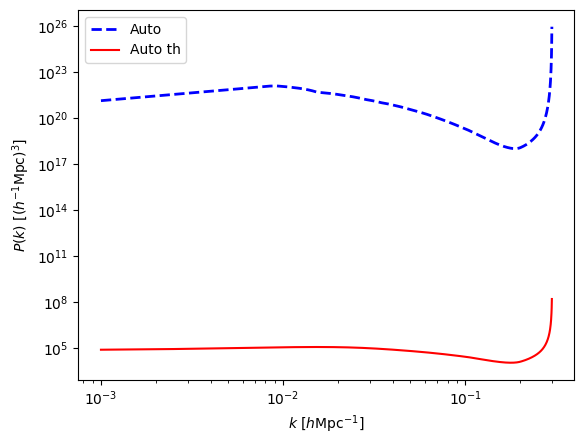

In [45]:
import matplotlib.pyplot as plt
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k~[h{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k)~[(h^{-1}{\rm Mpc})^3]$')

fac = 1#Ks**4
#plt.plot(Ks, (fac*abs(biass)*Pinterp), color= "brown", label = "Cross th")
#plt.plot(Ks, (fac*np.interp(Ks, kn, abs(powersn_ics)*growthf**-1.)*Ns), lw = 2, color = "cyan", ls = "--", label = "Cross")

plt.plot(Ks, (fac*np.interp(Ks, kn, powersn)*Ns**2), lw = 2, color = "blue", ls = "--", label = "Auto")
plt.plot(Ks, (fac*(biass**2*Pinterp+Ns)), color= "red", label = "Auto th")

#plt.plot(Ks, abs(fac*np.interp(Ks, k, Pk0_X_ics)*N*growthf**-1), lw = 2, color = "green", ls = "--")


#plt.loglog(kh_lin, pk_lin[0], label = "CAMB lin", color = "black")


plt.legend()
#plt.ylim(1e2)
#plt.xlim(1e-4, 1)
plt.show()

In [59]:
base_field_mesh = FieldMesh(delta_ivf.compute(mode='complex'))


for idir in range(3):
    # compute Psi_i
    def Psi_i_fcn(k3vec, val, idir=idir):
        kk = np.sum(ki**2 for ki in k3vec)  # k^2 on the mesh
        kk[kk == 0] = 1
        plinear_interp = plinf(kk)
        return -1.0j * k3vec[idir] * plinear_interp * val / kk

    Psi_i_x = base_field_mesh.apply(
        Psi_i_fcn, mode='complex',
        kind='wavenumber').compute(mode='real')

    product = (Psi_i_x * base_field_mesh.compute(mode='real'))
    product = FieldMesh(product)#.compute(mode='complex')
    
    # compute nabla_i delta
    def grad_i_fcn(k3vec, val, idir=idir):
        return -1.0j * k3vec[idir] * val

    final = product.apply(
        grad_i_fcn, mode='complex',
        kind='wavenumber').compute(mode='real')

    # multiply and add up in x space
    if idir == 0:
        out_rfield = final
    else:
        out_rfield += final

/tmp/ipykernel_52742/2128989089.py:7: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  kk = np.sum(ki**2 for ki in k3vec)  # k^2 on the mesh


In [44]:
delta_ivf_real = delta_ivf.compute(mode="real")
delta_wf_real = delta_wf.compute(mode="real")
delta_wf_shift_real = delta_wf_shift.compute(mode="real")

/tmp/ipykernel_65219/2141082570.py:2: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
/tmp/ipykernel_65219/2141082570.py:9: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh
/tmp/ipykernel_65219/2141082570.py:17: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  k2 = sum(ki**2 for ki in k3vec)  # |\vk|^2 on the mesh


In [97]:
growth_nbody = delta_ivf_real*delta_wf_real
shift_nbody = delta_ivf_real*delta_wf_shift_real

from nbodykit.algorithms.fftpower import FFTPower

r = FFTPower(growth_nbody, mode='1d', kmin = 1e-2)
Pk = r.power

# Extract k and P(k)
kn = Pk['k']
powern = Pk['power'].real
modesn = Pk['modes']

r = FFTPower(growth_nbody, second = delta_mesh, mode='1d', kmin = 1e-2)
Pk = r.power

# Extract k and P(k)
kn = Pk['k']
powercrossn = Pk['power'].real
modesn = Pk['modes']

r = FFTPower(shift_nbody, second = delta_mesh, mode='1d', kmin = 1e-2)
Pks = r.power

# Extract k and P(k)
kn = Pks['k']
powercrossns = Pks['power'].real
modesn = Pks['modes']

MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796
MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796
MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796
MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796
MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796
MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796


In [ ]:
shift_nbody_new = out_rfield
r = FFTPower(shift_nbody_new, second = delta_mesh, mode='1d', kmin = 1e-2)
Pks = r.power

# Extract k and P(k)
kn = Pks['k']
powercrossns_new = Pks['power'].real
modesn = Pks['modes']

r = FFTPower(shift_nbody_new, mode='1d', kmin = 1e-2)
Pks = r.power

# Extract k and P(k)
kn = Pks['k']
powershift = Pks['power'].real
modesn = Pks['modes']

MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796
MPSort: element size is large (12) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6796


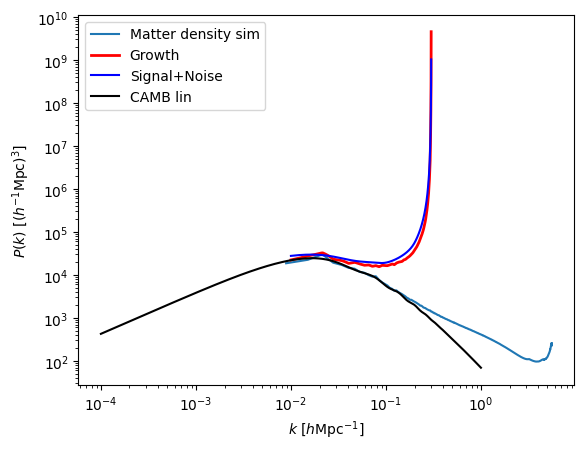

In [46]:
import matplotlib.pyplot as plt
plt.xscale('log')
plt.yscale('log')m
plt.xlabel(r'$k~[h{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k)~[(h^{-1}{\rm Mpc})^3]$')
plt.plot(k, Pk0, label = "Matter density sim")

plt.plot(Ks, np.interp(Ks, k, Pk0growth)*N**2, lw = 2, color = "red", label = "Growth")
plt.plot(Ks, Pinterp*bias**2+N, color= "blue", label = "Signal+Noise")
#plt.plot(Ks, N, lw = 2, color = "green", label = "Noise")
plt.loglog(kh_lin, pk_lin[0], label = "CAMB lin", color = "black")

plt.legend()

#plt.ylim(1e2, 1e5)
#plt.xlim(1e-4, 1)
plt.show()

In [ ]:
out = np.load("out.npy", allow_pickle = True).item()
out.keys()

key = "s"

Ks = out["Ks"]

N = out[(key, key)]**-1.

keys = ["g", "s", "t"]
bias = 0
for key_ in keys:
    try:
        invNk = out[(key, key_)]
    except:
        invNk = out[(key_, key)]
    bias += N*invNk

Pinterp = np.interp(Ks, kh_lin, pk_lin[0])

In [ ]:
import matplotlib.pyplot as plt
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k~[h{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k)~[(h^{-1}{\rm Mpc})^3]$')
plt.plot(k, Pk0, label = "Matter density sim")

plt.plot(Ks, Pinterp*bias**2+N, color= "blue", label = "Signal+Noise")
plt.plot(Ks, np.interp(Ks, knn, powershift)*N**2, lw = 2, color = "red", label = "Shift New", ls = "--")
#plt.plot(knn, powershift)
#plt.plot(Pkk['k'], Pkk['power'].real)

#plt.plot(Ks, np.interp(Ks, kn, powercrossns_new)*N, color = "orange")
#plt.plot(Ks, np.interp(Ks, k, Pk0_X_shift_n_ics)*N*growthf**-1., lw = 2, color = "green", label = "Shift New Cross", ls = "--")
#plt.plot(Ks, Pinterp*bias, color= "brown", label = "Signal")
#plt.loglog(kh_lin, pk_lin[0], label = "CAMB lin", color = "black")

plt.legend()
#normalization_ivf, normalization_wf
#plt.ylim(1e2, 1e5)
#plt.xlim(1e-4, 1)
plt.show()